In [1]:

# visualisation
from IPython.display import display, Math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import cm
import seaborn as sns

import pandas as pd
import numpy as np
import sys
import numbers

# pathlib
from pathlib import Path
# 
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    silhouette_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve, 
    auc,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn import tree

from scipy.cluster.hierarchy import linkage, dendrogram

from mlxtend.frequent_patterns import apriori, association_rules

from xgboost import XGBClassifier

In [2]:

from torch.utils.data import DataLoader
from torchvision.transforms import v2

In [3]:

LCL_PATH   = str(Path().cwd())
ROOT_PATH  = str(Path(LCL_PATH).parent)
DEEPL_PATH = "/home/gheorghe/Desktop/Proiecte/master/DeepLearning"
DS_PATH  = str(Path(ROOT_PATH)/"data")
info_msg = """
root path:\t{}
local path:\t{}
dataset path:\t{}
deep learning path:\t{}""".format(ROOT_PATH, LCL_PATH, DS_PATH, DEEPL_PATH)
print(info_msg)


root path:	/home/gheorghe/Desktop/Proiecte/master/DM
local path:	/home/gheorghe/Desktop/Proiecte/master/DM/task05
dataset path:	/home/gheorghe/Desktop/Proiecte/master/DM/data
deep learning path:	/home/gheorghe/Desktop/Proiecte/master/DeepLearning


In [4]:

# adding local_folder to the system path
sys.path.append(LCL_PATH)
sys.path.append(ROOT_PATH)
sys.path.append(DEEPL_PATH)

from sys_function import * # este in root

In [5]:

sys_remove_modules("imshow")
sys_remove_modules("cross_validation.apply_K_fold")

sys_remove_modules("common.dataset.supervised_dataset")
sys_remove_modules("common.dataset.normalize_by_column")
sys_remove_modules("common.models.ann")
sys_remove_modules("common.models.ann_p0")

sys_remove_modules("trainer.supervised_callback_metrics_trainer")
sys_remove_modules("checks.tensor_check")
sys_remove_modules("callback.show_logs")
sys_remove_modules("callback.save_model_by_best_key")
sys_remove_modules("callback.extern_stoping")
sys_remove_modules("metrics.accuracy")
sys_remove_modules("metrics.f1_score")


from imshow import *
from cross_validation.apply_K_fold import *

from common.dataset.supervised_dataset import *
from common.dataset.normalize_by_column import *
from common.models.ann import *
from common.models.ann_p0 import *

from trainer.supervised_callback_metrics_trainer import *
from checks.tensor_check import *
from callback.show_logs import *
from callback.save_model_by_best_key import *
from callback.extern_stoping import *
from metrics.accuracy import *
from metrics.f1_score import *


First we define some configuration variables

In [6]:

FEATURE_SIZE = 11
NUM_CLASSES  = 2
BATCH_SIZE = 32

## Func

In [7]:

def show_metrics(y_test, y_pred, class_names=["negative", "positive"]):
    acc = accuracy_score(y_test, y_pred)
    display(Math(r"\mathrm{{Accuracy}} = {:.3f}<=> \frac{{TP + TN}}{{TP + TN + FP + FN}}".format(acc)))
    precision = precision_score(y_test, y_pred)
    display(Math(r"\mathrm{{Precision}} = {:.3f}<=> \frac{{TP}}{{TP + FP}}".format(precision)))
    recall = recall_score(y_test, y_pred)
    display(Math(r"\mathrm{{Recall}} = {:.3f}<=> \frac{{TP}}{{TP + FN}}".format(recall)))
    f1 = f1_score(y_test, y_pred)
    display(Math(r"\mathrm{{F1 Score}} = {:.3f}<=> \frac{{2*precision*recall}}{{precision+recall}}".format(f1)))
    auc = roc_auc_score(y_test, y_pred)
    display(Math(r"\mathrm{{AUC}} = {:.3f}<=> \mathrm{{1.0 → perfect classifier, 0.5 → random guessing}}".format(auc)))
    # Compute contigency matrix
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot()
    plt.title("Confusion Matrix")
    plt.show()
    
    # ROC values
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    
    # plot
    plt.figure(figsize=(6,6))
    
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    
    # diagonal random classifier
    plt.plot([0, 1], [0, 1], linestyle='--')
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_pred)
    
    plt.title("ROC Curve")
    plt.show()

In [8]:

def get_best_K_models(X_train, y_train, grid_search, model_fn, K=3, **kw):
    # Convert results to DataFrame, select best parameters
    results = pd.DataFrame(grid_search.cv_results_)
    # Sort by validation accuracy
    top_K_parameters = results.sort_values(
        by="mean_test_score",
        ascending=False
    )
    # select best K parameters
    top_K_parameters = top_K_parameters["params"].head(K).tolist()
    # add best K parameters
    top_models = []
    for idx, params in enumerate(top_K_parameters):
        params.update(kw)
        model = model_fn(
            **params
        )
        # fit models
        model.fit(X_train, y_train)
        top_models.append(("model_{}".format(idx), model))
    return top_models

In [9]:

def cast_to_int(pd_df, columns):
    for column in columns:
        values = pd.unique(pd_df[column])
        d = dict()
        for ecode_val, value in enumerate(values):
            d[value] = ecode_val
        print(d)
        def apply_cast(data):
            return d[data]
        pd_df[column] = pd_df[column].apply(apply_cast)
    return pd_df

In [10]:

def concatArr2Df(args, column="label"):
    for param in args:
        print(param.shape)
    arr = np.concatenate(args, axis=-1)
    print(arr.shape)

    columns=[f"F{i}" for i in range(arr.shape[1])]
    columns[-1] = "Label"
    df = pd.DataFrame(arr.astype(bool), columns=columns)
    return df


def filterLabel(data):
    if ("Label" in data):
        return data
    else:
        return None

In [11]:

def calculate(one_hot_categorical, continuous_X, Y, strategy="uniform", min_support=0.4, min_threshold=0.4, n_bins=[200, 300, 200, 100]):
    # Initializing and setting the parameters n_bins to 3, encode to ordinal and strategy to uniform
    discretizer = KBinsDiscretizer(n_bins=n_bins, encode="onehot", strategy=strategy)
    
    # Fitting and transforming the data into n_bins number of bins
    one_hot_continuous = discretizer.fit_transform(continuous_X).toarray()
    one_hot_continuous
    
    # df = one-hot encoded transaction matrix
    df = concatArr2Df((one_hot_categorical, one_hot_continuous, Y.reshape(-1, 1)), None)
    frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
    
    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_threshold
    )
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
    
    rules = rules[["antecedents", "consequents", "support", "confidence"]]
    rules["consequents"] = rules["consequents"].apply(filterLabel)
    rules = rules.dropna()
    display(rules)

# Data aquisition

In [12]:

filename = "{}/heart_failure_prediction/heart.csv".format(DS_PATH)
pd_df = pd.read_csv(filename, 
                    #names=["col0", "col1", "col2", "col3", "labels"], 
                    #header=None
                   )
N_CLUSTERS = 2

In [13]:
pd_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [14]:
pd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


<Axes: xlabel='HeartDisease', ylabel='Count'>

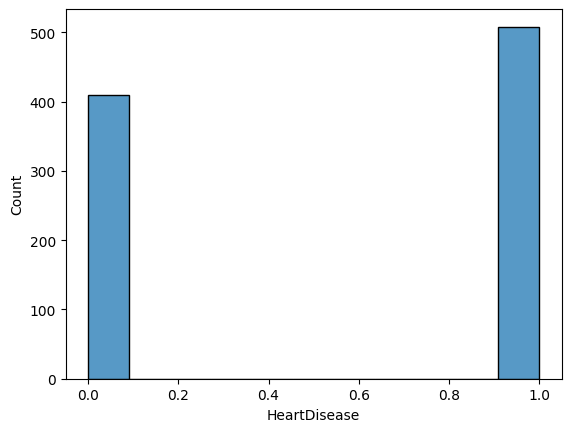

In [15]:

# the age distribution
sns.histplot(data=pd_df, x="HeartDisease")

In [16]:

pd_X = pd_df.drop(columns=["HeartDisease"])
pd_Y = pd_df["HeartDisease"]

# Converting the categorical to numeric features, and other preprocessing steps (such as filling missing values). 

In [17]:

X = cast_to_int(pd_X.copy(), columns=["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]).to_numpy()
Y = pd_Y.to_numpy()

{'M': 0, 'F': 1}
{'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3}
{'Normal': 0, 'ST': 1, 'LVH': 2}
{'N': 0, 'Y': 1}
{'Up': 0, 'Flat': 1, 'Down': 2}


# Study the impact of filter feature selection for two classifiers from the list below (different from decision trees), using the conclusions from task 3 homework 1.

In [18]:

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2, f_classif

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [33]:

# Configuration
RANDOM_STATE = 42

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

SCORING = "f1"   # change to accuracy / roc_auc if needed

In [34]:

# Define Models
models = {
    "rf": RandomForestClassifier(random_state=RANDOM_STATE),
    "logreg": LogisticRegression(max_iter=2000)
}

In [35]:

# Feature Selection Methods
# We define valid score functions + required preprocessing rules.
feature_selectors = {
    "mutual_info": mutual_info_classif,
    "f_classif": f_classif,
    "chi2": chi2
}

In [36]:

# Preprocessing rules (important)
# chi2 → requires non-negative data → MinMaxScaler
# others → StandardScaler
def get_scaler(score_func):
    if score_func == chi2:
        return MinMaxScaler()
    return StandardScaler()

In [37]:

# Pipeline Builder
# This is the core abstraction.
def build_pipeline(model, score_func):
    return Pipeline([
        ("scaler", get_scaler(score_func)),
        ("select", SelectKBest(score_func=score_func)),
        ("clf", model)
    ])

In [38]:

# Parameter grids
# We define search space per model.
# Shared feature selection params
k_values = [5, 10, 20, 50]

In [39]:

# Random Forest grid
rf_grid = {
    "select__k": k_values,
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20]
}

# Logistic Regression grid
logreg_grid = {
    "select__k": k_values,
    "clf__C": [0.1, 1, 10]
}

In [40]:

# Attach grids dynamically
param_grids = {
    "rf": rf_grid,
    "logreg": logreg_grid
}

In [41]:

# Experiment Runner
# This runs everything cleanly and stores results
def run_experiments(X, y):
    results = []

    for model_name, model in models.items():
        for fs_name, score_func in feature_selectors.items():

            pipeline = build_pipeline(model, score_func)

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grids[model_name],
                scoring=SCORING,
                cv=cv,
                n_jobs=-1
            )

            grid.fit(X, y)

            results.append({
                "model": model_name,
                "feature_selection": fs_name,
                "best_score": grid.best_score_,
                "best_params": grid.best_params_
            })

            print(f"{model_name} + {fs_name}: {grid.best_score_:.4f}")

    return pd.DataFrame(results)

In [42]:

# Run Experiment
results_df = run_experiments(X, Y)
print(results_df)

/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=50 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=5

rf + mutual_info: 0.8833


/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=2

rf + f_classif: 0.8852


/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=2

rf + chi2: 0.8814


/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=2

logreg + mutual_info: 0.8696
logreg + f_classif: 0.8693
logreg + chi2: 0.8769
    model feature_selection  best_score  \
0      rf       mutual_info    0.883333   
1      rf         f_classif    0.885215   
2      rf              chi2    0.881402   
3  logreg       mutual_info    0.869567   
4  logreg         f_classif    0.869299   
5  logreg              chi2    0.876936   

                                         best_params  
0  {'clf__max_depth': 10, 'clf__n_estimators': 20...  
1  {'clf__max_depth': 10, 'clf__n_estimators': 20...  
2  {'clf__max_depth': None, 'clf__n_estimators': ...  
3                   {'clf__C': 0.1, 'select__k': 10}  
4                   {'clf__C': 0.1, 'select__k': 20}  
5                     {'clf__C': 10, 'select__k': 5}  


/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=2

In [43]:

print(results_df)

    model feature_selection  best_score  \
0      rf       mutual_info    0.883333   
1      rf         f_classif    0.885215   
2      rf              chi2    0.881402   
3  logreg       mutual_info    0.869567   
4  logreg         f_classif    0.869299   
5  logreg              chi2    0.876936   

                                         best_params  
0  {'clf__max_depth': 10, 'clf__n_estimators': 20...  
1  {'clf__max_depth': 10, 'clf__n_estimators': 20...  
2  {'clf__max_depth': None, 'clf__n_estimators': ...  
3                   {'clf__C': 0.1, 'select__k': 10}  
4                   {'clf__C': 0.1, 'select__k': 20}  
5                     {'clf__C': 10, 'select__k': 5}  


# Using 5-fold cross validation (performed for each instantiation of the classifier’s hyperparameters)

## Splitting the dataset in 5 folds, in a stratified manner (considering the distribution of the values of the feature).

In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [19]:
best_models = dict()

### Decision trees
* Hyperparameter tuning (the impurity measure, the maximum depth of the tree, the number of features to consider when looking for the best split, …)
* Visualization of the trees 
* Comparative study of the  selected features compared to the 3rd task from homework 1: “In view of a subsequent classification analysis, identify the variables that have predictive power for the target variable.”) 

* criterion: Determines how the quality of a split is measured.
    - gini:Gini impurity, good separation. (Faster computation, Default in DecisionTreeClassifier, Lower impurity = better split)
    - entropy: (Measures disorder/randomness, Usually slightly slower, Sometimes gives better splits)
* max_depth: Maximum depth of the tree.
    - Small depth (3, 5), (Simpler model, Less overfitting, More generalization)
    - Large depth (10),   (More complex, Learns detailed patterns, Risk of overfitting)
    - None, (Tree grows until: all leaves are pure, or splitting stops because of other constraints, this can create very large trees)
* max_features: How many features are considered at each split.
    - None, Uses all features. (Potentially best split, Slower, Higher overfitting risk)
    - sqrt, (For 100 features: only 10 random features are checked per split.)
    - log2, (For 100 features: only 6 random features are checked per split.)
* min_samples_split: Minimum number of samples required to split a node.
* min_samples_leaf: Minimum number of samples allowed in a leaf node.

In [35]:

# Hyperparameter tuning (the impurity measure, the maximum depth of the tree, 
#         the number of features to consider when looking for the best split, …)
# Splitting the dataset in 5 folds, in a stratified manner (considering the distribution of the values of the feature).
# Repeatedly training on 4 folds and collecting, each time, the predictions on the validation fold.
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 20, None],
    'max_features': [None, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,     # Splitting the dataset in 5 folds
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_models["DecisionTree"] = grid_search
print("Best parameters:")
print(grid_search.best_params_)

print("Best CV accuracy:")
print(grid_search.best_score_)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Best parameters:
{'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV accuracy:
0.8296803652968038


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

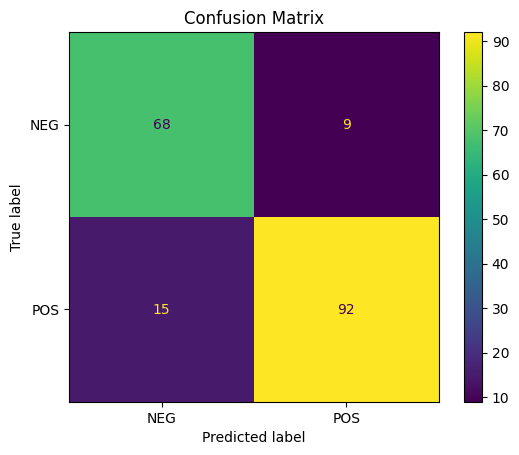

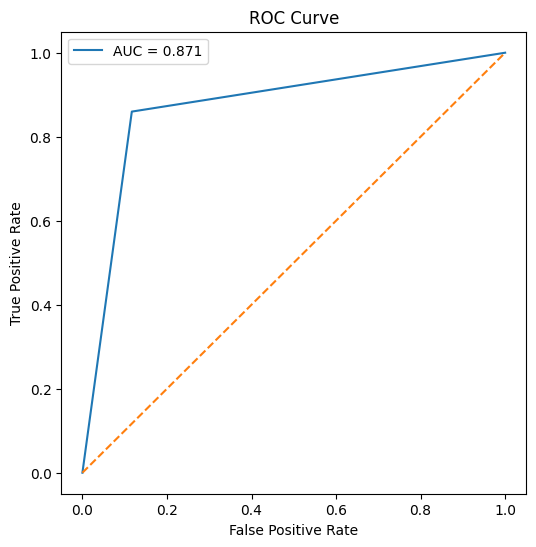

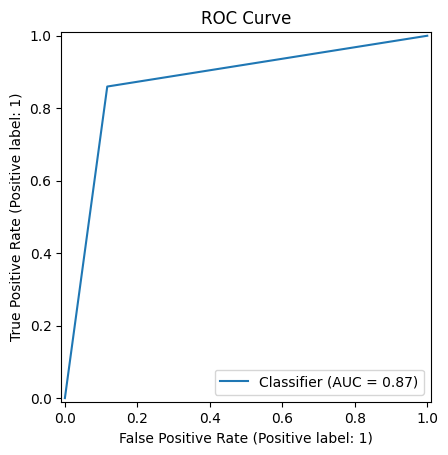

In [36]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = grid_search.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

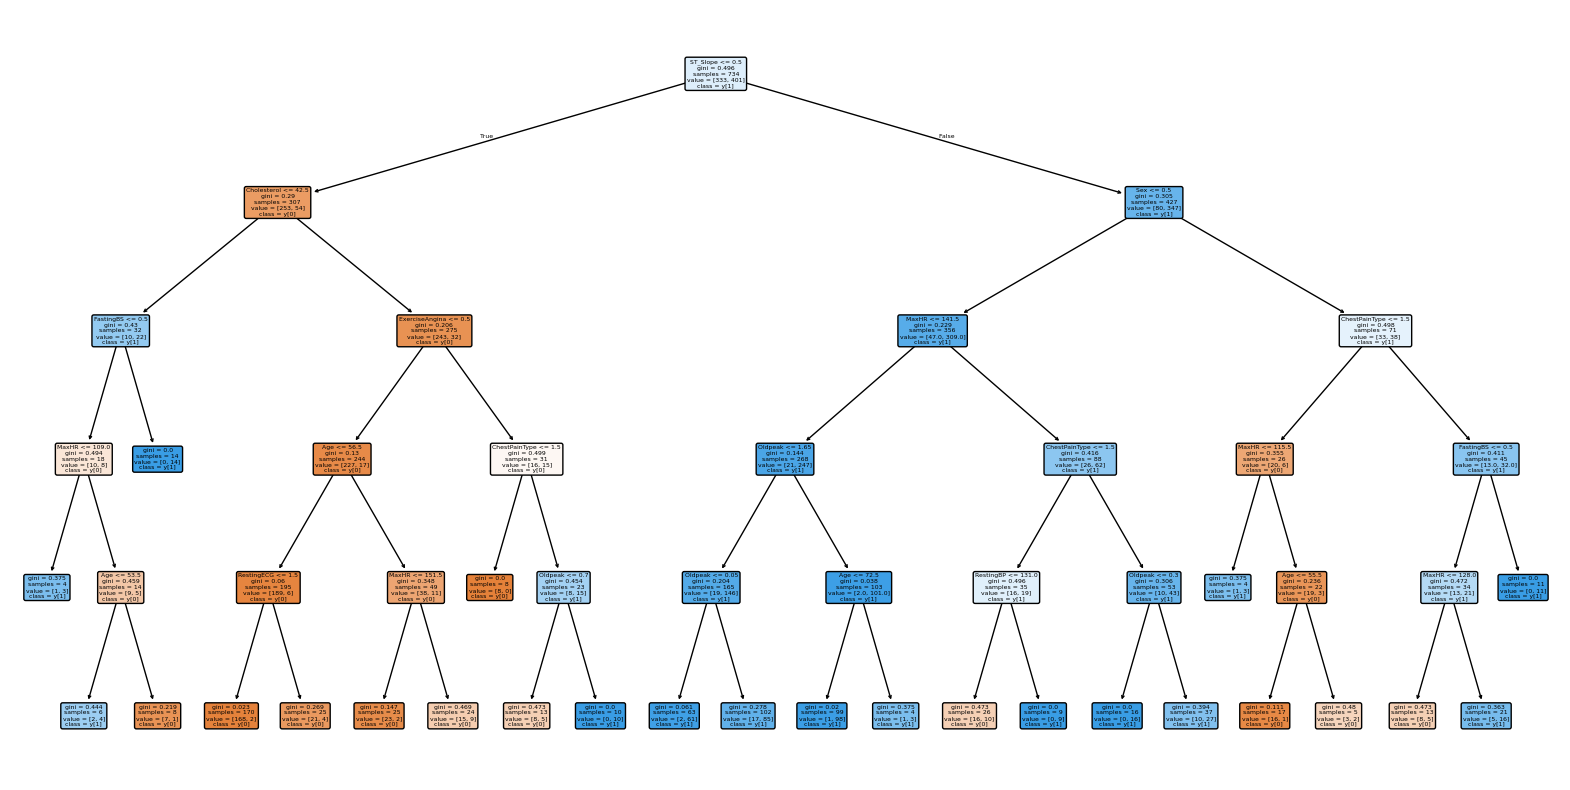

In [37]:

# Visualization of the trees
best_tree = grid_search.best_estimator_

plt.figure(figsize=(20,10))

tree.plot_tree(
    best_tree,
    feature_names=pd_X.columns,
    class_names=True,
    filled=True,
    rounded=True
)

plt.show()

In [38]:

# Feature importance
importance = best_tree.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": pd_X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
10        ST_Slope    0.593459
4      Cholesterol    0.076631
2    ChestPainType    0.064302
7            MaxHR    0.058070
1              Sex    0.053721
8   ExerciseAngina    0.038674
9          Oldpeak    0.034803
5        FastingBS    0.029878
0              Age    0.025788
3        RestingBP    0.020750
6       RestingECG    0.003925


In [39]:

top_models = get_best_K_models(X_train, y_train, grid_search, model_fn=DecisionTreeClassifier, K=3)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

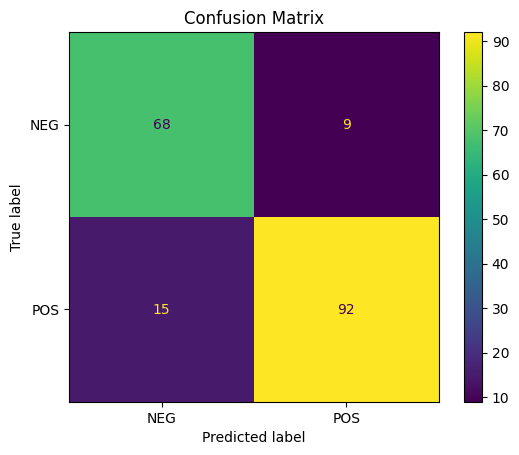

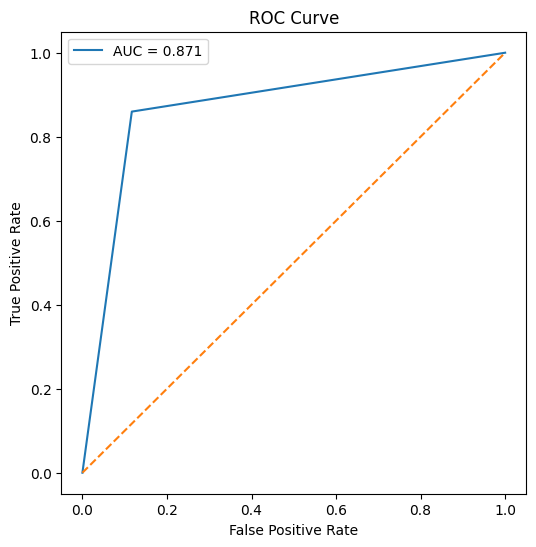

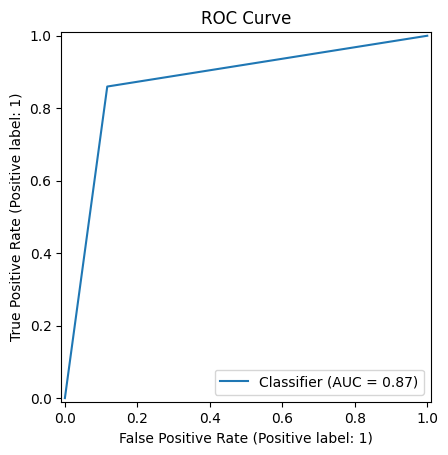

In [40]:

# Show metrics, hard voting
ensemble = VotingClassifier(
    estimators=top_models,
    voting="hard"
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

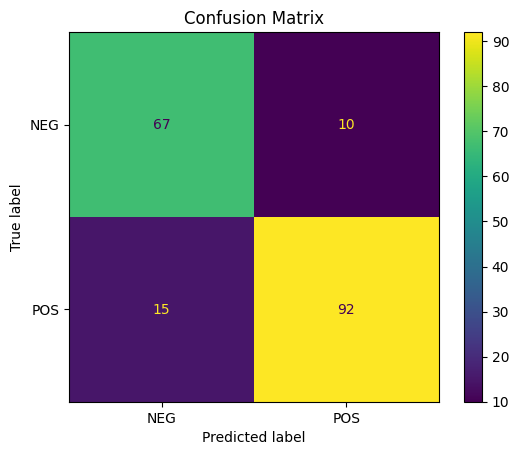

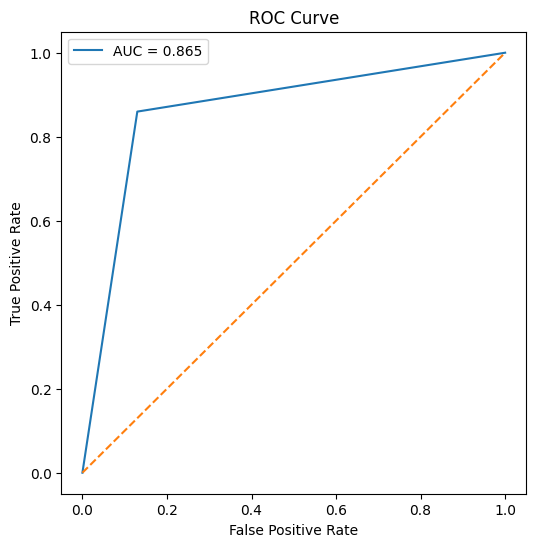

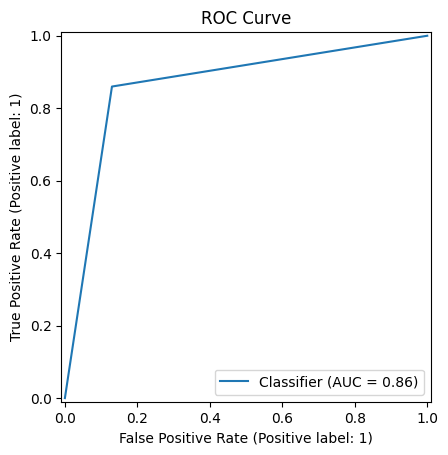

In [41]:

# Show metrics, soft voting
ensemble = VotingClassifier(
    estimators=top_models,
    voting='soft'
)

ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

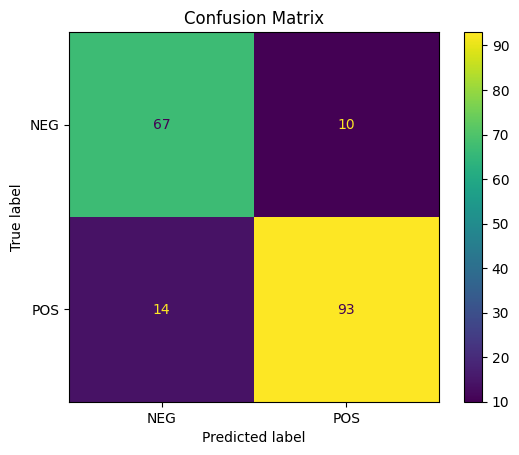

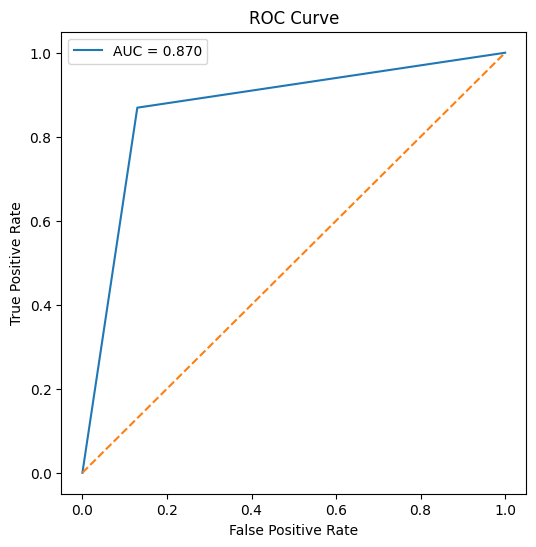

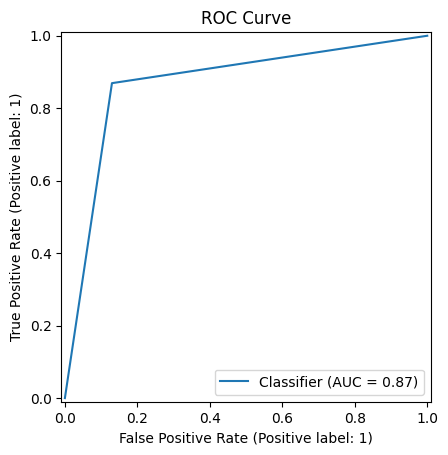

In [42]:

# Show metrics, stacking classifier
stack_model = StackingClassifier(
    estimators=top_models,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)
y_pred = stack_model.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

### kNN
* Impact of feature standardization (impact on the distance)
* Hyperparameter tuning (distance function, number of neighbors, weighted final score,...)

* n_neighbors - Number of nearest neighbors used for classification.
    - The algorithm finds the k closest training samples
    - The predicted class is determined from those neighbors
    - | Small `k`                 | Large `k`         |
| ------------------------- | ----------------- |
| Sensitive to noise        | More stable       |
| Can overfit               | Can underfit      |
| Complex decision boundary | Smoother boundary |
* weights - Controls how neighbors contribute to prediction.
    - uniform - All neighbors vote equally.
    - distance - Closer neighbors get larger influence. A nearby point contributes more than a far one.
* metric - Defines how distance between samples is computed.
    - euclidean - Standard geometric distance.
    - manhattan - City-block distance.
    - minkowski - Generalized distance. p = 1 → Manhattan, p = 2 → Euclidean

In [43]:

# Hyperparameter tuning (the impurity measure, the maximum depth of the tree, 
#         the number of features to consider when looking for the best split, …)
# Splitting the dataset in 5 folds, in a stratified manner (considering the distribution of the values of the feature).
# Repeatedly training on 4 folds and collecting, each time, the predictions on the validation fold.
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_models["KNeighbors"] = grid_search
print("Best parameters:")
print(grid_search.best_params_)

print("Best CV accuracy:")
print(grid_search.best_score_)

Best parameters:
{'metric': 'manhattan', 'n_neighbors': 17, 'p': 1, 'weights': 'distance'}
Best CV accuracy:
0.7574596962072501


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

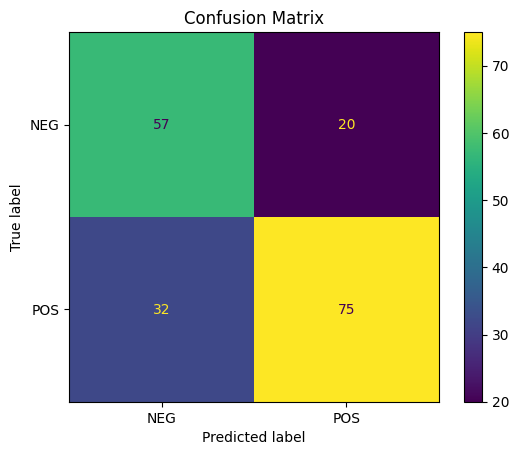

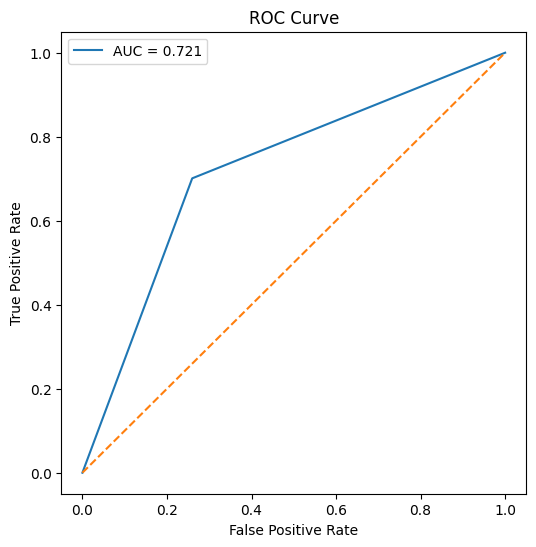

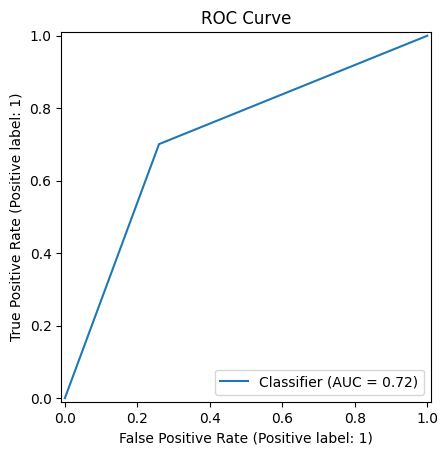

In [44]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = grid_search.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

In [45]:

top_models = get_best_K_models(X_train, y_train, grid_search, model_fn=KNeighborsClassifier, K=3)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

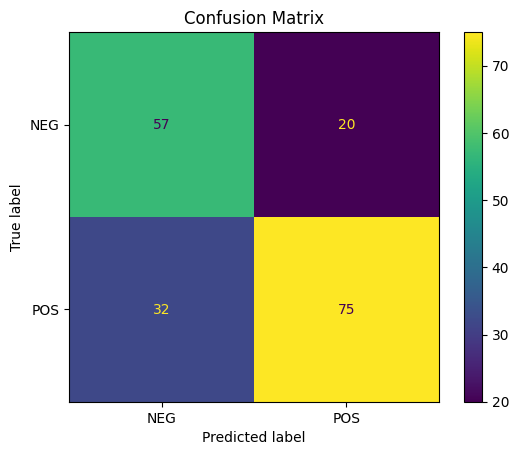

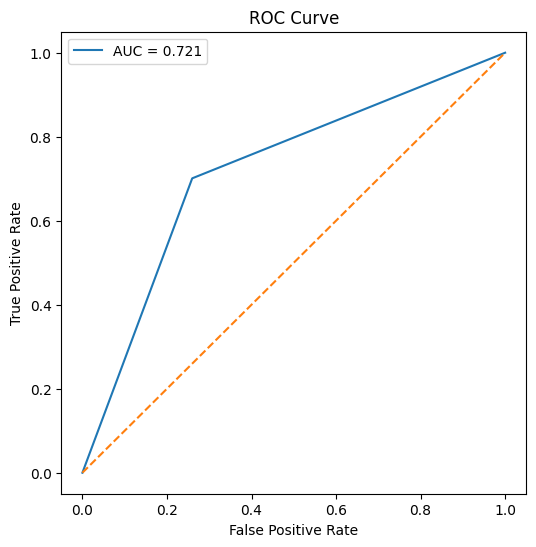

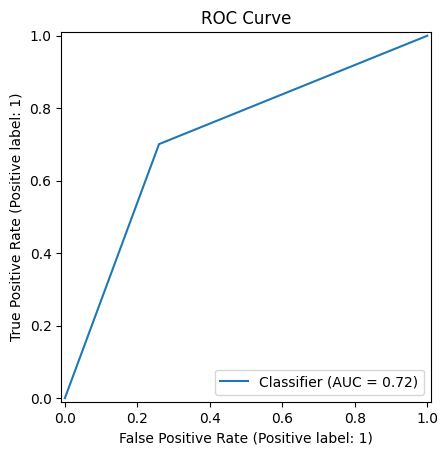

In [46]:

# Show metrics, hard voting
ensemble = VotingClassifier(
    estimators=top_models,
    voting="hard"
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

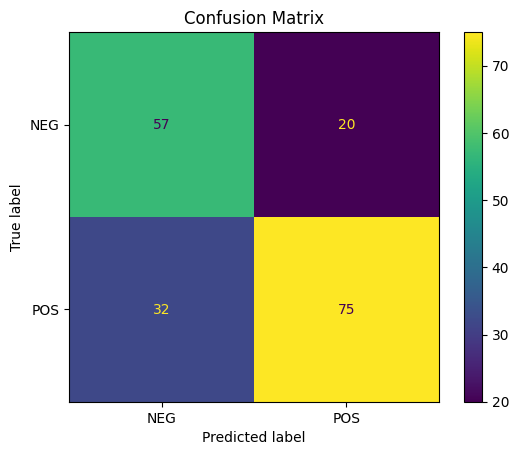

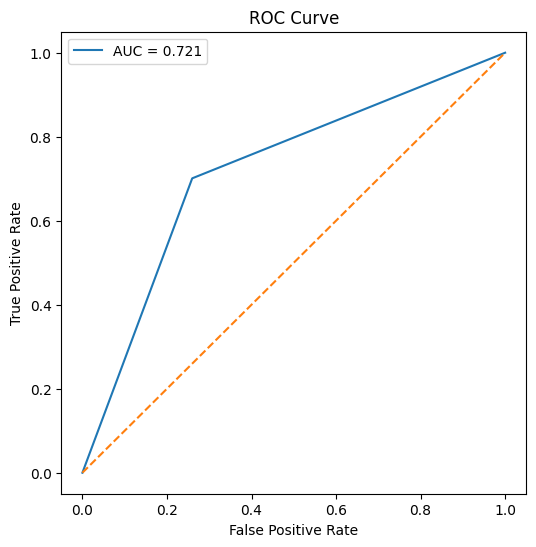

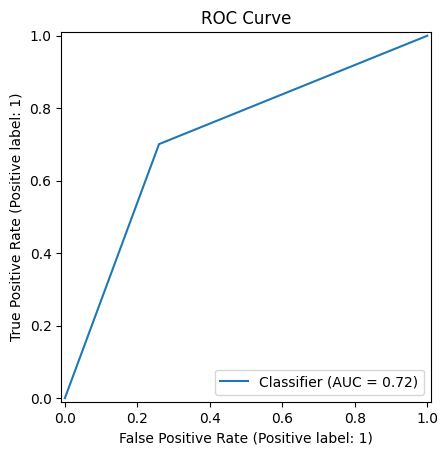

In [47]:

# Show metrics, hard voting
ensemble = VotingClassifier(
    estimators=top_models,
    voting="soft"
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

### Naive Bayes (for numerical features)
* Hyperparameter tuning

* var_smoothing - This parameter stabilizes variance calculations. Internally, GaussianNB adds a small value to feature variances
Why this is needed
    - Sometimes:
        - a feature has extremely small variance
        - variance becomes nearly zero
    - This can cause:
        - numerical instability
        - division by zero
        - exploding probabilities
Why logarithmic spacing?

    - Tiny changes can strongly affect performance.
    - Logarithmic spacing tests:
        - very large values
        - medium values
        - extremely small values

In [48]:

# Hyperparameter tuning (the impurity measure, the maximum depth of the tree, 
#         the number of features to consider when looking for the best split, …)
# Splitting the dataset in 5 folds, in a stratified manner (considering the distribution of the values of the feature).
# Repeatedly training on 4 folds and collecting, each time, the predictions on the validation fold.
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_search = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_models["GaussianNB"] = grid_search
print("Best parameters:")
print(grid_search.best_params_)

print("Best CV accuracy:")
print(grid_search.best_score_)

Best parameters:
{'var_smoothing': np.float64(6.579332246575682e-07)}
Best CV accuracy:
0.8623986580933745


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

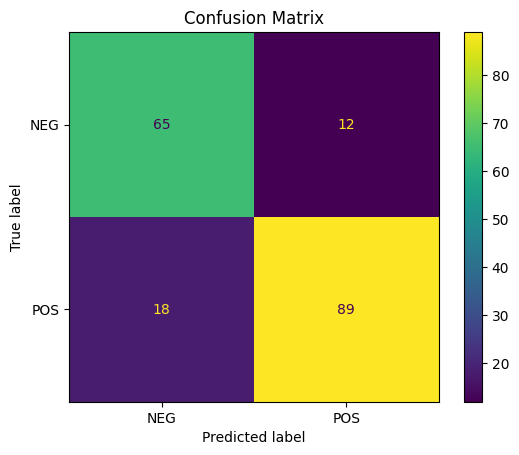

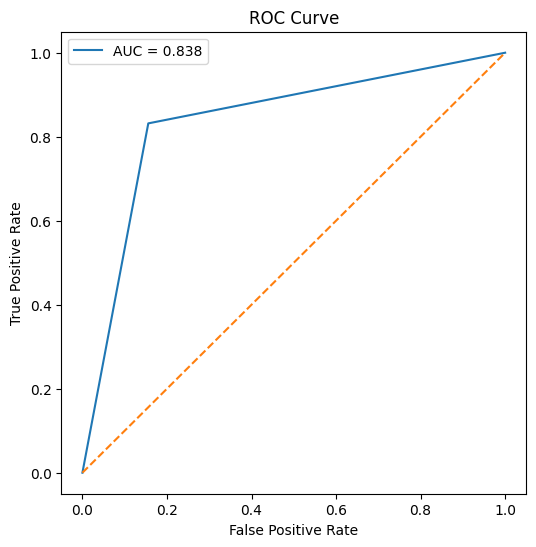

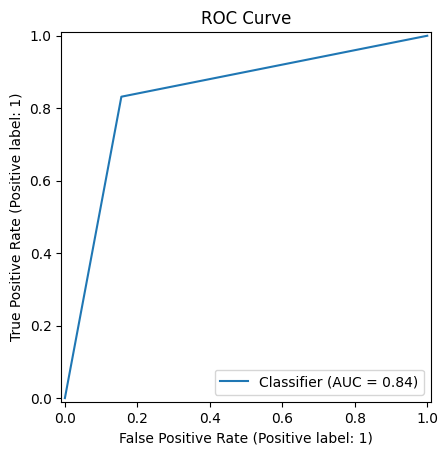

In [49]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = grid_search.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

In [50]:

top_models = get_best_K_models(X_train, y_train, grid_search, model_fn=GaussianNB, K=3)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

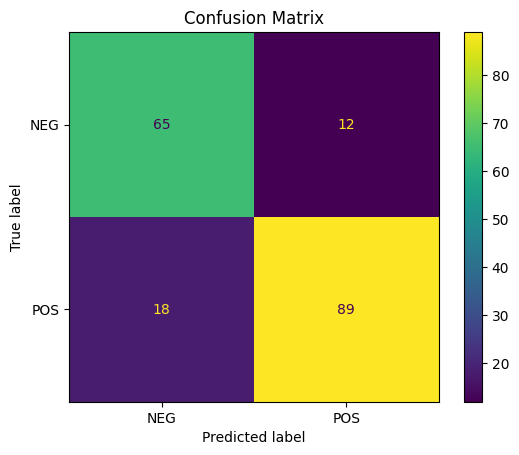

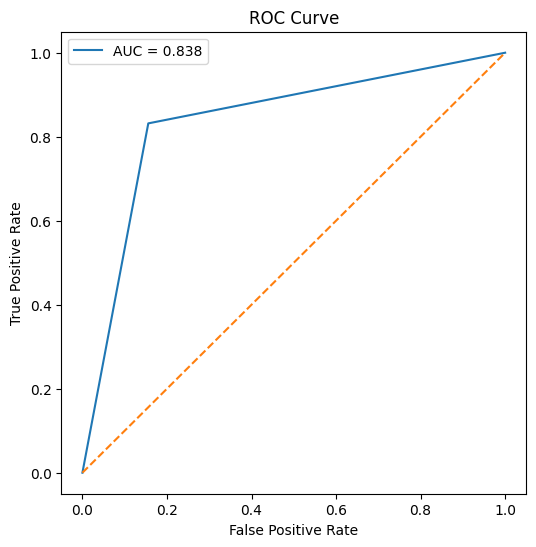

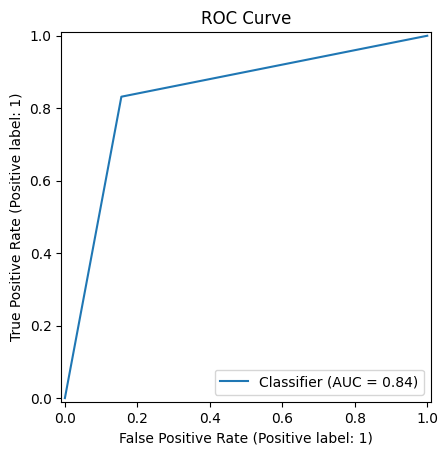

In [51]:

# Show metrics, hard voting
ensemble = VotingClassifier(
    estimators=top_models,
    voting="hard"
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

### SVM 
* Impact of feature standardization 
* Hyperparameter tuning (kernel function, numerical parameters)

In [37]:

# Hyperparameter tuning (the impurity measure, the maximum depth of the tree, 
#         the number of features to consider when looking for the best split, …)
# Splitting the dataset in 5 folds, in a stratified manner (considering the distribution of the values of the feature).
# Repeatedly training on 4 folds and collecting, each time, the predictions on the validation fold.
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'degree': [2, 3, 4]
    }
]

grid_search = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_models["SVM"] = grid_search
print("Best parameters:")
print(grid_search.best_params_)

print("Best CV accuracy:")
print(grid_search.best_score_)

KeyboardInterrupt: 

In [ ]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = grid_search.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

In [ ]:

top_models = get_best_K_models(X_train, y_train, grid_search, model_fn=SVC, K=3)

In [ ]:

# Show metrics, hard voting
ensemble = VotingClassifier(
    estimators=top_models,
    voting="hard"
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

### Ensemble strategies 
* Bagging: Random forest, with hyper-parameter tuning
* Boosting: xgBoost with hyper-parameter tuning

In [52]:

# Hyperparameter tuning (the impurity measure, the maximum depth of the tree, 
#         the number of features to consider when looking for the best split, …)
# Splitting the dataset in 5 folds, in a stratified manner (considering the distribution of the values of the feature).
# Repeatedly training on 4 folds and collecting, each time, the predictions on the validation fold.
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

grid_search = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_models["XGB"] = grid_search
print("Best parameters:")
print(grid_search.best_params_)

print("Best CV accuracy:")
print(grid_search.best_score_)

Best parameters:
{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best CV accuracy:
0.8733016494268939


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

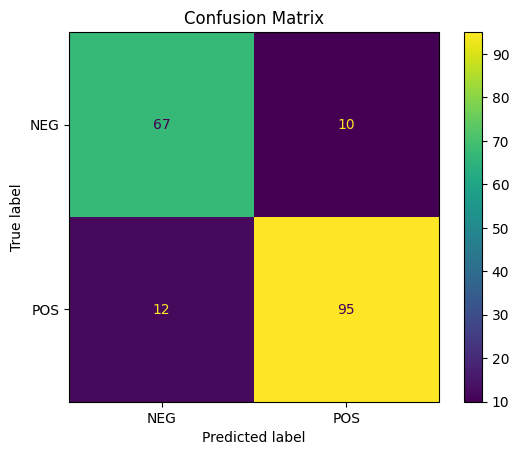

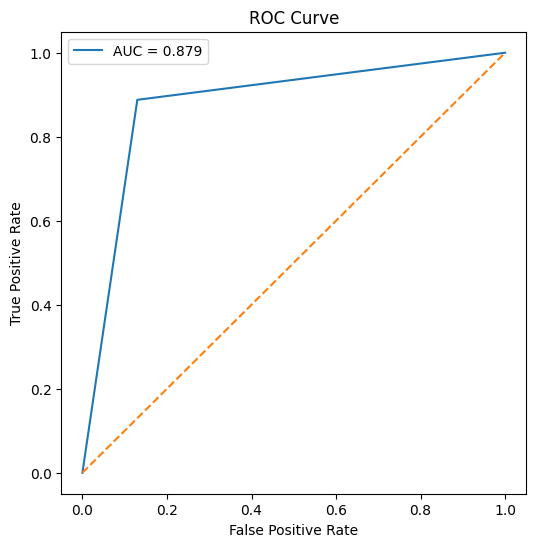

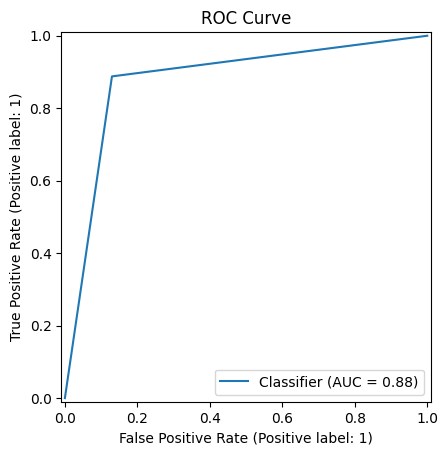

In [53]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = grid_search.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

In [54]:

top_models = get_best_K_models(X_train, y_train, grid_search, 
                               model_fn=XGBClassifier, K=3, 
                               random_state=42,
                               eval_metric='logloss')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

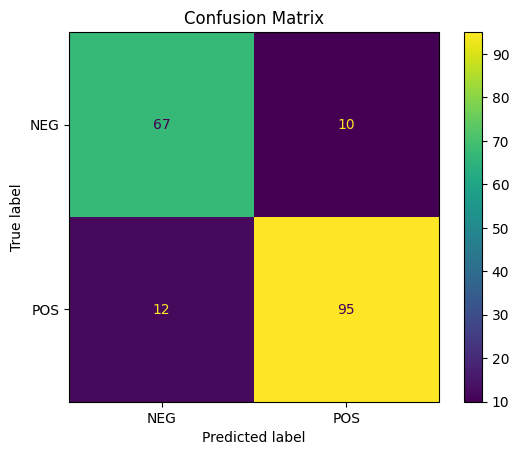

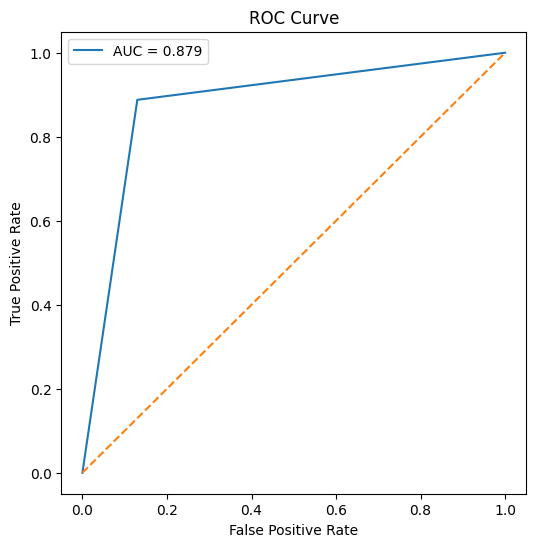

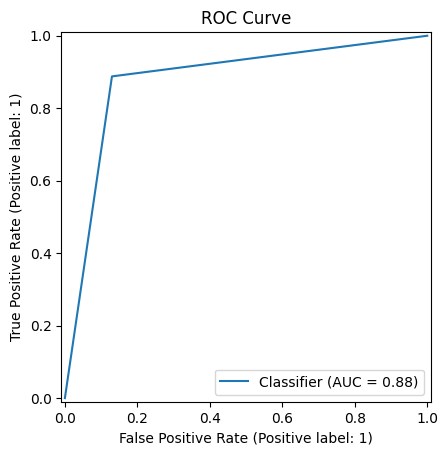

In [55]:

# Show metrics, hard voting
ensemble = VotingClassifier(
    estimators=top_models,
    voting="hard"
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

### Stacking

In [56]:

top_models = []
for name_model in best_models.keys():
    print(name_model)
    top_models.append((name_model, best_models[name_model]))

DecisionTree
KNeighbors
GaussianNB
XGB


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

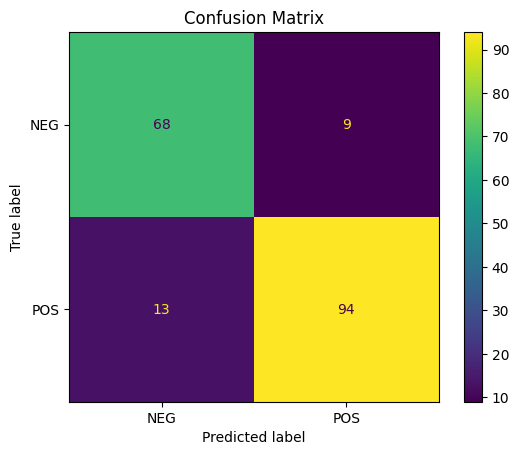

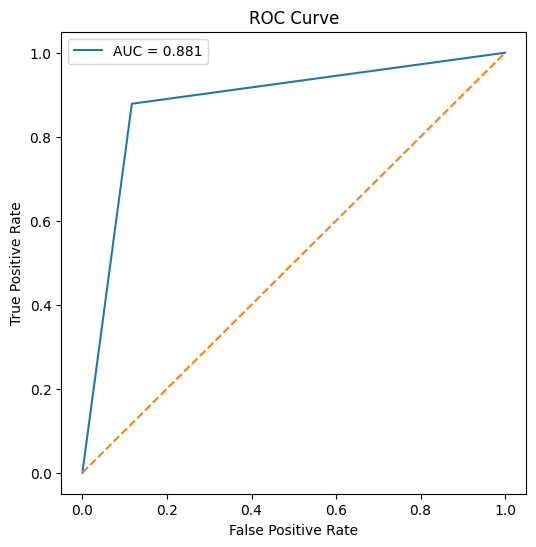

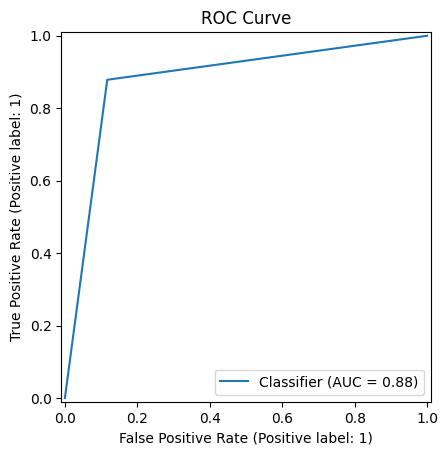

In [57]:

# Show metrics, soft voting
ensemble = VotingClassifier(
    estimators=top_models,
    voting="soft"
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

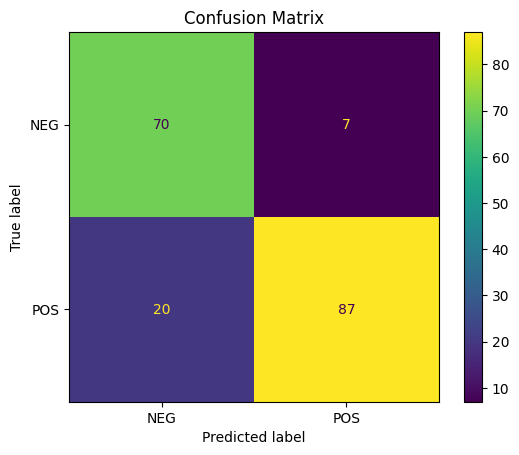

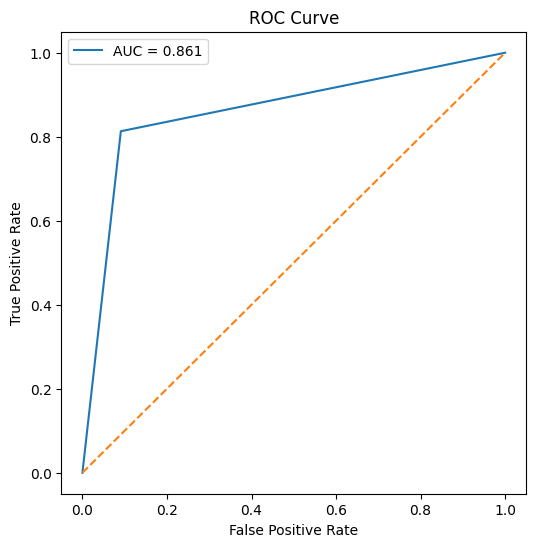

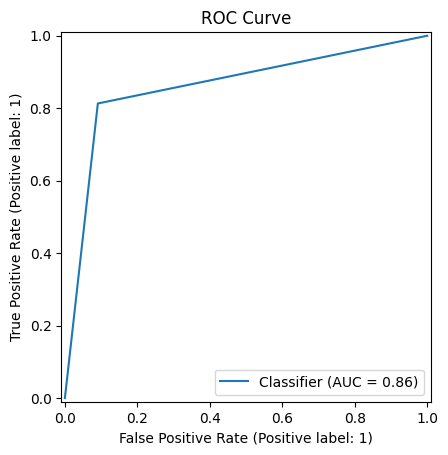

In [58]:

# Show metrics, hard voting
ensemble = VotingClassifier(
    estimators=top_models,
    voting="hard"
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

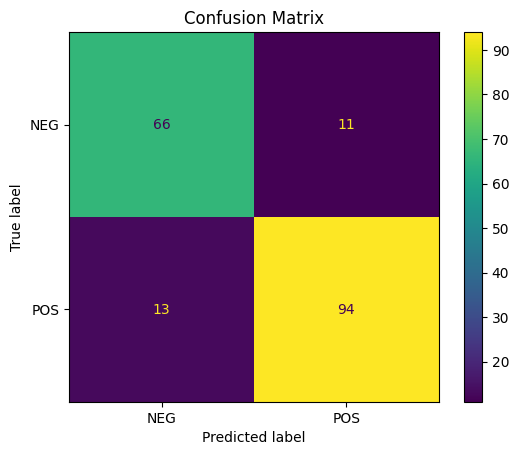

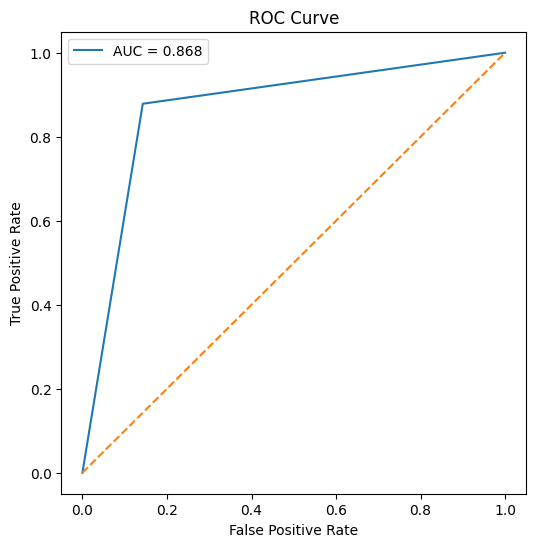

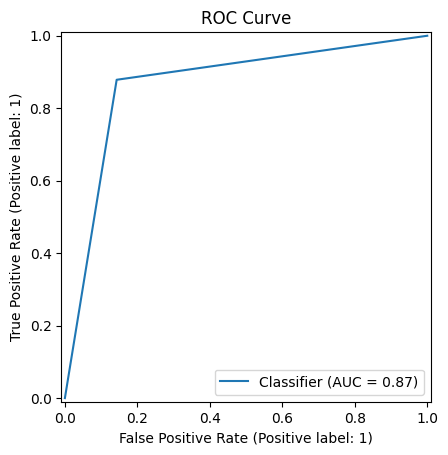

In [59]:

# Show metrics, stacking classifier
stack_model = StackingClassifier(
    estimators=top_models,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)
y_pred = stack_model.predict(X_test)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

# Neural networks 
* Optimizing the architecture (number of layers, neurons per layer, activation functions)
* Optimizing the hyper-parameters (learning rate, training algorithm)
* Impact of feature standardization 


## Znorm

### Data aquisition

In [26]:

norm_by_column_obj = NormalizeByColumn(X, norn_type="z_norm")

In [27]:

#X_train, y_train
# min max normalize
train_X = norm_by_column_obj(X_train).astype(np.float32)
test_X  = norm_by_column_obj(X_test).astype(np.float32)
# Dataset
train_ds = SupervisedDataset(dict(inputs=train_X, targets=y_train))
test_ds  = SupervisedDataset(dict(inputs=test_X,  targets=y_test))

In [28]:
X_train.shape

(734, 11)

In [29]:

# perform 100 read test, of images from files, with transformation
in_arg = (
    (11, ),         # shape
    1,              # max_val
    -1,             # min_val
    np.float32,     # dtype
    None,           # arr_type
)
out_arg = (
    (),             # shape
    1,              # max_val
    0,              # min_val
    np.int64,       # dtype
    None,           # arr_type
)
print("Check train----------------------")
check_pipeline(train_ds, size=100, in_arg=in_arg, out_arg=out_arg)
print("Check test-----------------------")
check_pipeline(test_ds,  size=100, in_arg=in_arg, out_arg=out_arg)

Check train----------------------
OK
Check test-----------------------
OK


In [30]:

# select the best number workers
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, drop_last=False)

### Train

In [31]:

device = torch.device("cuda")

In [32]:

model = ANN_P0(FEATURE_SIZE, NUM_CLASSES)
criterion = nn.CrossEntropyLoss(reduction="mean", label_smoothing=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-7)

model_name = "ann_p0_znorm_ca_ce_v0"
save_image_clbk_path = "{}/logs/{}".format(LCL_PATH, model_name)
save_model_clbk_path = "{}/logs/{}.pth".format(LCL_PATH, model_name)
extern_cmd_clbk_path = "{}/extern_command.cmd".format(LCL_PATH)
   
callbacks = [ShowLogs("Adam"), 
             SaveModelByBestKey(model, save_model_clbk_path, meta_file=None, key="val_mae"),
             ExternStoping(extern_cmd_clbk_path)
            ]
metrics   = {"acc": Acuracy(name="accuracy"), 
             "f1_score":F1Score(num_classses=NUM_CLASSES, name="f1_score")}


trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transform=None, 
        val_transform=None, 
        lr_scheduler=lr_scheduler,
        pred_unpack_fn=lambda pred: pred.argmax(dim=-1)
)

Using device: cuda


/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


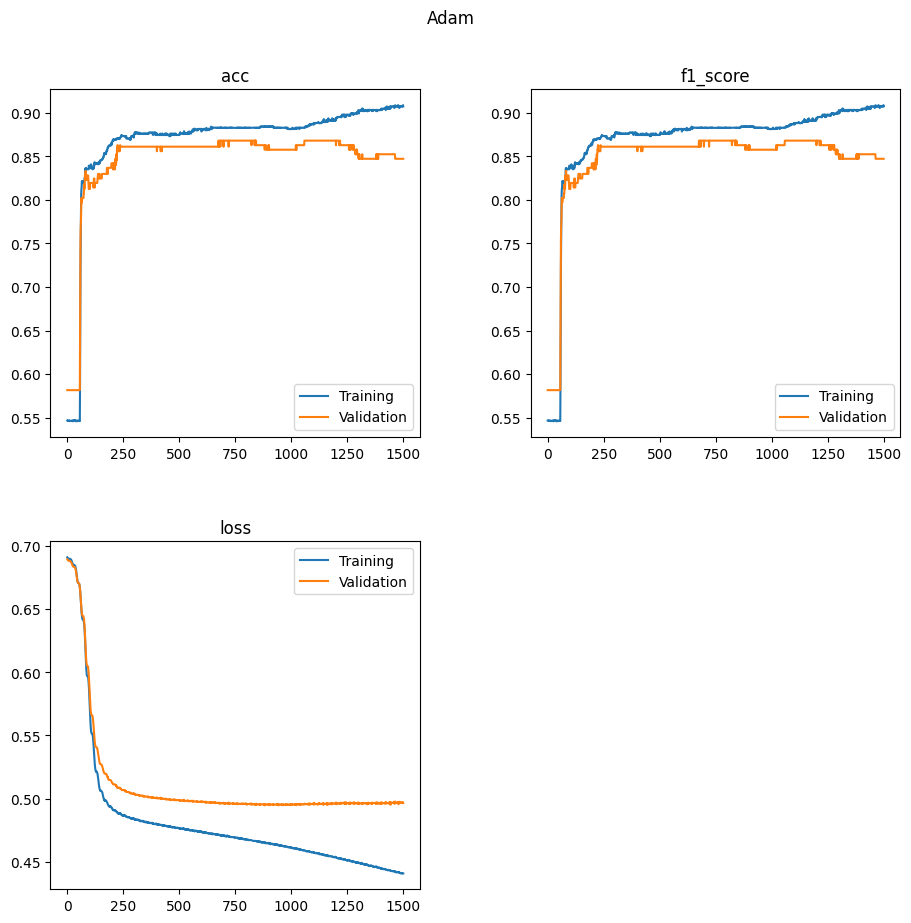

loss:
	min: 0.44072,	max: 0.69113,	cur: 0.44074
acc:
	min: 0.54583,	max: 0.90888,	cur: 0.90743
f1_score:
	min: 0.54583,	max: 0.90888,	cur: 0.90743
val_loss:
	min: 0.49462,	max: 0.68959,	cur: 0.49654
val_acc:
	min: 0.5816,	max: 0.86806,	cur: 0.84722
val_f1_score:
	min: 0.5816,	max: 0.86806,	cur: 0.84722
Epoch: 1500



In [33]:

EPOCH = 1500
trainer_obj.run(train_dl, test_dl, EPOCH)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

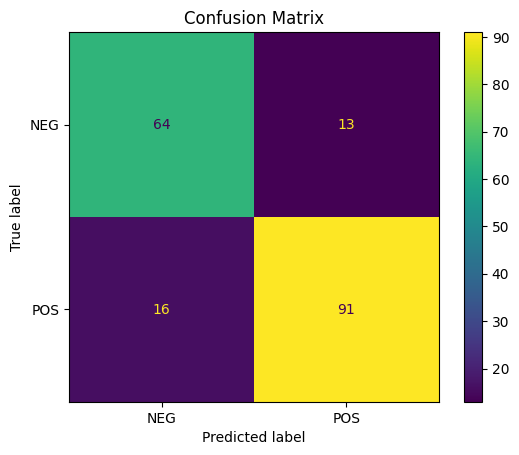

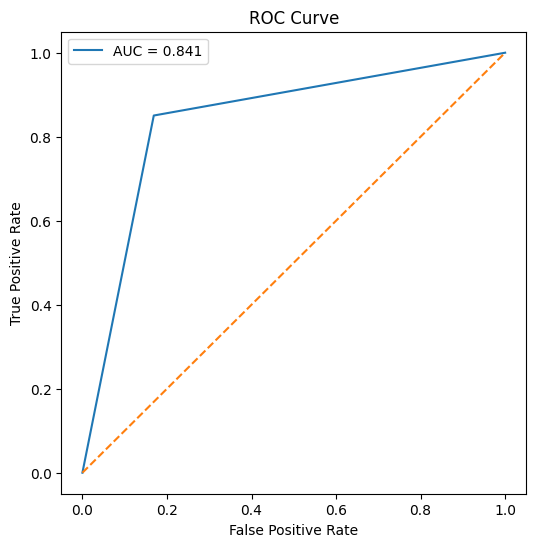

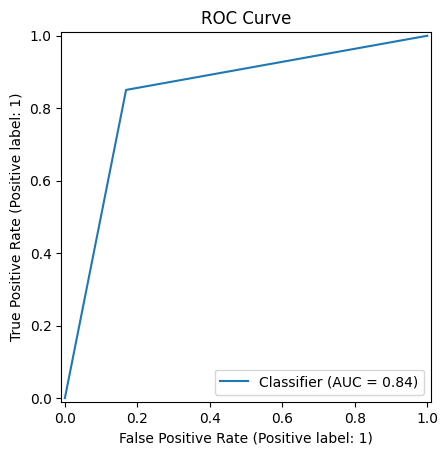

In [34]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = trainer_obj.predict(test_dl)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

In [63]:

model = ANN_P0(FEATURE_SIZE, NUM_CLASSES)
criterion = nn.CrossEntropyLoss(reduction="mean", label_smoothing=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-7)

model_name = "ann_p0_znorm_ca_ce_v1"
save_image_clbk_path = "{}/logs/{}".format(LCL_PATH, model_name)
save_model_clbk_path = "{}/logs/{}.pth".format(LCL_PATH, model_name)
extern_cmd_clbk_path = "{}/extern_command.cmd".format(LCL_PATH)
   
callbacks = [ShowLogs("Adam"), 
             SaveModelByBestKey(model, save_model_clbk_path, meta_file=None, key="val_mae"),
             ExternStoping(extern_cmd_clbk_path)
            ]
metrics   = {"acc": Acuracy(name="accuracy"), 
             "f1_score":F1Score(num_classses=NUM_CLASSES, name="f1_score")}


trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transform=None, 
        val_transform=None, 
        lr_scheduler=lr_scheduler,
        pred_unpack_fn=lambda pred: pred.argmax(dim=-1)
)

Using device: cuda


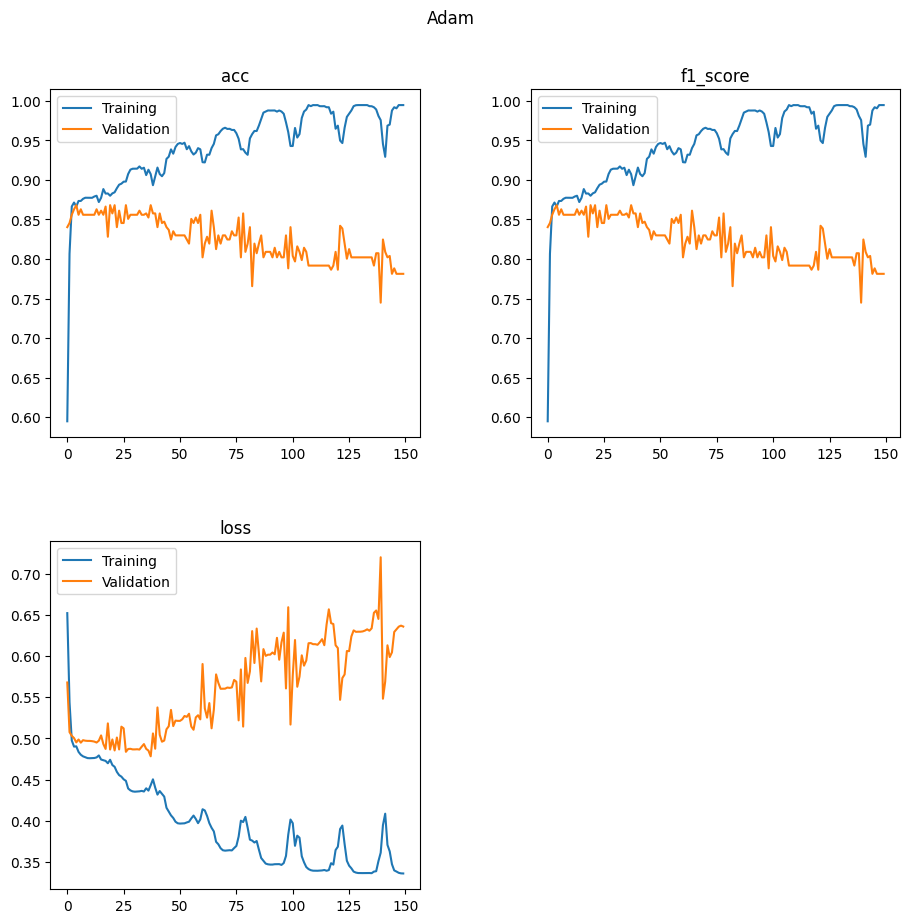

loss:
	min: 0.33609,	max: 0.65216,	cur: 0.33609
acc:
	min: 0.59484,	max: 0.99457,	cur: 0.99457
f1_score:
	min: 0.59484,	max: 0.99457,	cur: 0.99457
val_loss:
	min: 0.47832,	max: 0.71998,	cur: 0.63586
val_acc:
	min: 0.74479,	max: 0.86806,	cur: 0.78125
val_f1_score:
	min: 0.74479,	max: 0.86806,	cur: 0.78125
Epoch: 150



In [64]:

EPOCH = 150
trainer_obj.run(train_dl, test_dl, EPOCH)

In [ ]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = trainer_obj.predict(test_dl)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

In [65]:

model = ANN_P0(FEATURE_SIZE, NUM_CLASSES)
criterion = nn.CrossEntropyLoss(reduction="mean", label_smoothing=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000, eta_min=1e-7)

model_name = "ann_p0_znorm_ca_ce_v2"
save_image_clbk_path = "{}/logs/{}".format(LCL_PATH, model_name)
save_model_clbk_path = "{}/logs/{}.pth".format(LCL_PATH, model_name)
extern_cmd_clbk_path = "{}/extern_command.cmd".format(LCL_PATH)
   
callbacks = [ShowLogs("Adam"), 
             SaveModelByBestKey(model, save_model_clbk_path, meta_file=None, key="val_mae"),
             ExternStoping(extern_cmd_clbk_path)
            ]
metrics   = {"acc": Acuracy(name="accuracy"), 
             "f1_score":F1Score(num_classses=NUM_CLASSES, name="f1_score")}


trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transform=None, 
        val_transform=None, 
        lr_scheduler=lr_scheduler,
        pred_unpack_fn=lambda pred: pred.argmax(dim=-1)
)

Using device: cuda


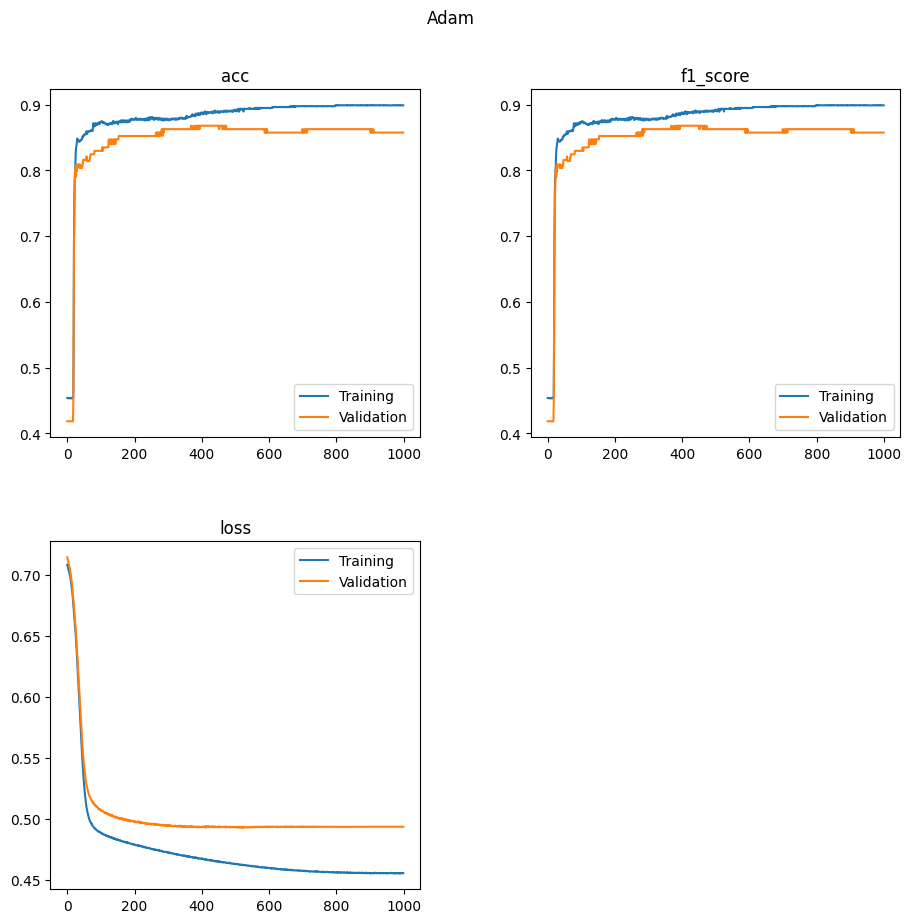

loss:
	min: 0.45513,	max: 0.70819,	cur: 0.4554
acc:
	min: 0.45335,	max: 0.89946,	cur: 0.89909
f1_score:
	min: 0.45335,	max: 0.89946,	cur: 0.89909
val_loss:
	min: 0.49266,	max: 0.71444,	cur: 0.49344
val_acc:
	min: 0.4184,	max: 0.86806,	cur: 0.85764
val_f1_score:
	min: 0.4184,	max: 0.86806,	cur: 0.85764
Epoch: 1000



In [66]:

EPOCH = 1000
trainer_obj.run(train_dl, test_dl, EPOCH)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

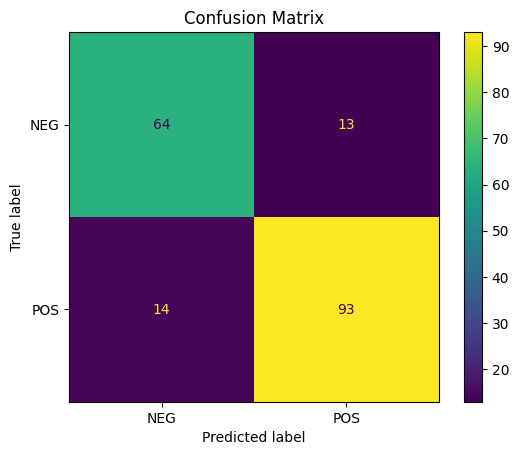

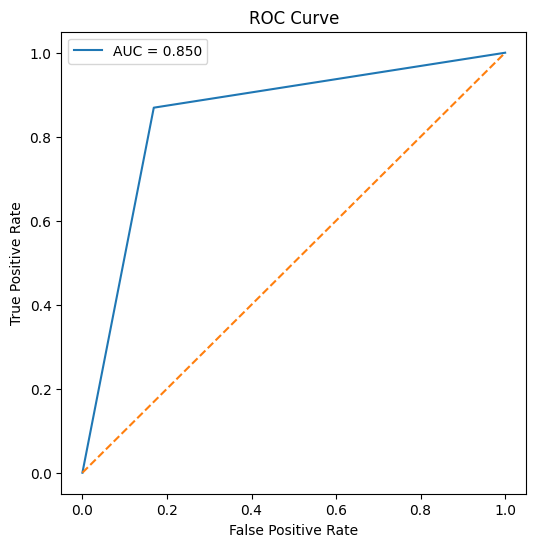

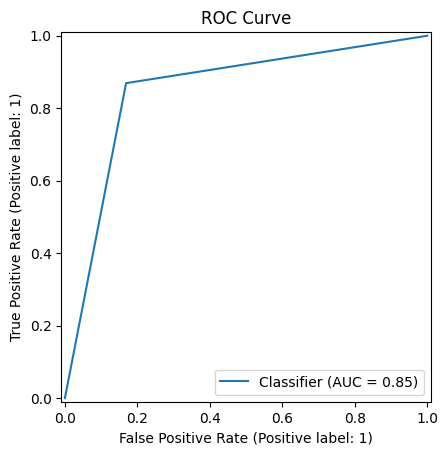

In [67]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = trainer_obj.predict(test_dl)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

In [68]:

model = ANN(FEATURE_SIZE, NUM_CLASSES)
criterion = nn.CrossEntropyLoss(reduction="mean", label_smoothing=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-7)

model_name = "ann_znorm_ca_ce_v2"
save_image_clbk_path = "{}/logs/{}".format(LCL_PATH, model_name)
save_model_clbk_path = "{}/logs/{}.pth".format(LCL_PATH, model_name)
extern_cmd_clbk_path = "{}/extern_command.cmd".format(LCL_PATH)
   
callbacks = [ShowLogs("Adam"), 
             SaveModelByBestKey(model, save_model_clbk_path, meta_file=None, key="val_mae"),
             ExternStoping(extern_cmd_clbk_path)
            ]
metrics   = {"acc": Acuracy(name="accuracy"), 
             "f1_score":F1Score(num_classses=NUM_CLASSES, name="f1_score")}


trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transform=None, 
        val_transform=None, 
        lr_scheduler=lr_scheduler,
        pred_unpack_fn=lambda pred: pred.argmax(dim=-1)
)

Using device: cuda


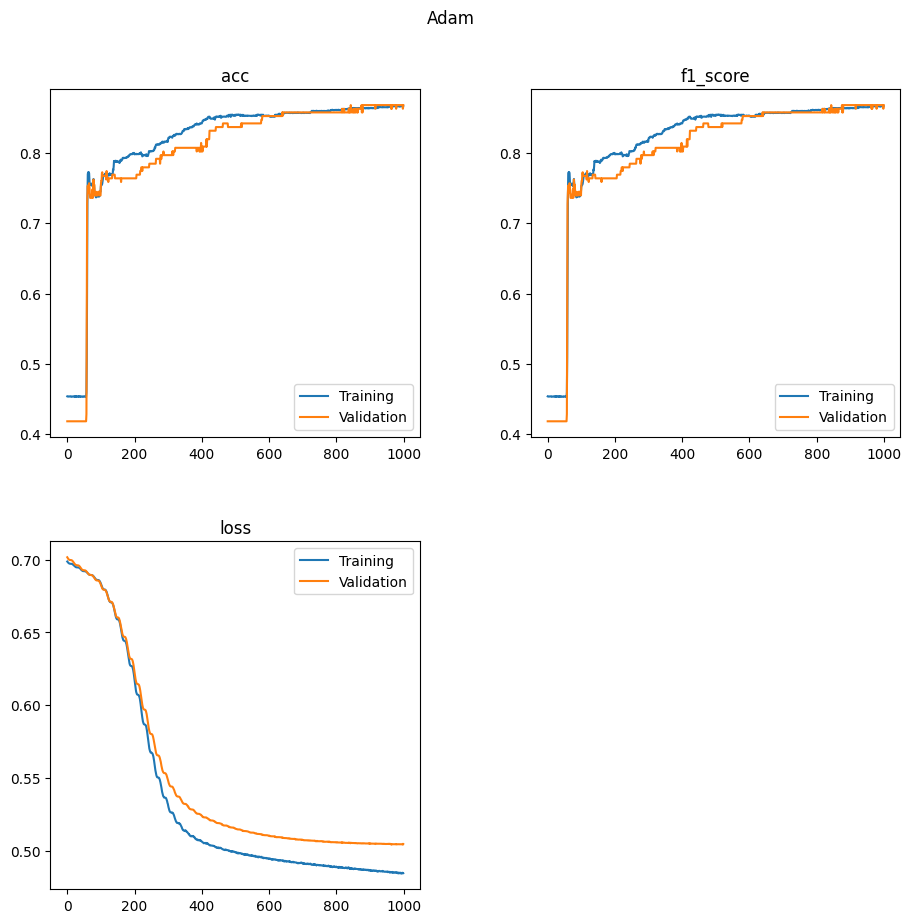

loss:
	min: 0.48443,	max: 0.69866,	cur: 0.4846
acc:
	min: 0.45308,	max: 0.86685,	cur: 0.86658
f1_score:
	min: 0.45308,	max: 0.86685,	cur: 0.86658
val_loss:
	min: 0.50424,	max: 0.70157,	cur: 0.50462
val_acc:
	min: 0.4184,	max: 0.86806,	cur: 0.86806
val_f1_score:
	min: 0.4184,	max: 0.86806,	cur: 0.86806
Epoch: 1000



In [69]:

EPOCH = 1000
trainer_obj.run(train_dl, test_dl, EPOCH)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

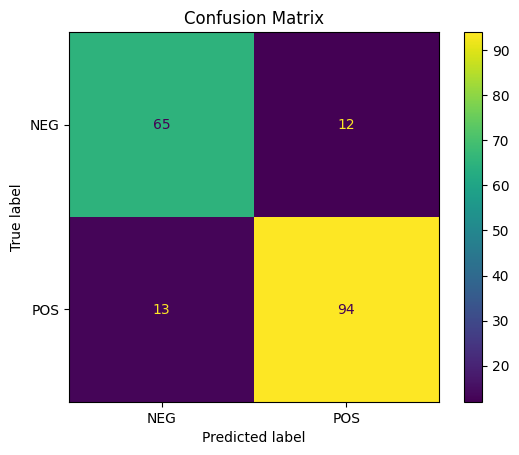

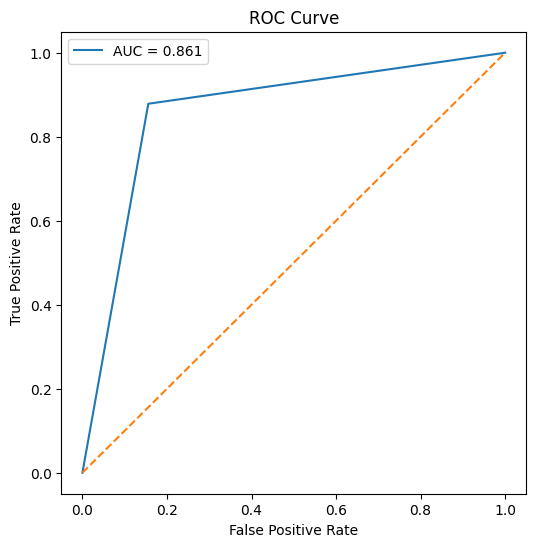

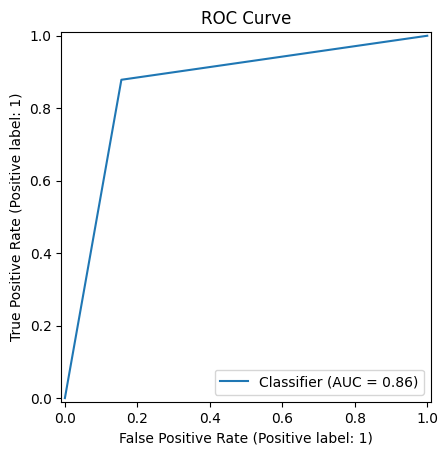

In [70]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = trainer_obj.predict(test_dl)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])

## Min max norm

### Data aquisition

In [71]:

norm_by_column_obj = NormalizeByColumn(X, norn_type="min_max")

In [72]:

#X_train, y_train
# min max normalize
train_X = norm_by_column_obj(X_train).astype(np.float32)
test_X  = norm_by_column_obj(X_test).astype(np.float32)
# Dataset
train_ds = SupervisedDataset(dict(inputs=train_X, targets=y_train))
test_ds  = SupervisedDataset(dict(inputs=test_X,  targets=y_test))

In [73]:

# perform 100 read test, of images from files, with transformation
in_arg = (
    (11, ),         # shape
    1,              # max_val
    0,              # min_val
    np.float32,     # dtype
    None,           # arr_type
)
out_arg = (
    (),             # shape
    1,              # max_val
    0,              # min_val
    np.int64,       # dtype
    None,           # arr_type
)
print("Check train----------------------")
check_pipeline(train_ds, size=100, in_arg=in_arg, out_arg=out_arg)
print("Check test-----------------------")
check_pipeline(test_ds,  size=100, in_arg=in_arg, out_arg=out_arg)

Check train----------------------
OK
Check test-----------------------
OK


In [74]:

# select the best number workers
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, drop_last=False)

### Train

In [75]:
device = torch.device("cuda")

In [76]:

model = ANN_P0(FEATURE_SIZE, NUM_CLASSES)
criterion = nn.CrossEntropyLoss(reduction="mean", label_smoothing=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-7)

model_name = "ann_p0_min_max_ca_ce_v0"
save_image_clbk_path = "{}/logs/{}".format(LCL_PATH, model_name)
save_model_clbk_path = "{}/logs/{}.pth".format(LCL_PATH, model_name)
extern_cmd_clbk_path = "{}/extern_command.cmd".format(LCL_PATH)
   
callbacks = [ShowLogs("Adam"), 
             SaveModelByBestKey(model, save_model_clbk_path, meta_file=None, key="val_mae"),
             ExternStoping(extern_cmd_clbk_path)
            ]
metrics   = {"acc": Acuracy(name="accuracy"), 
             "f1_score":F1Score(num_classses=NUM_CLASSES, name="f1_score")}


trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transform=None, 
        val_transform=None, 
        lr_scheduler=lr_scheduler,
        pred_unpack_fn=lambda pred: pred.argmax(dim=-1)
)

Using device: cuda


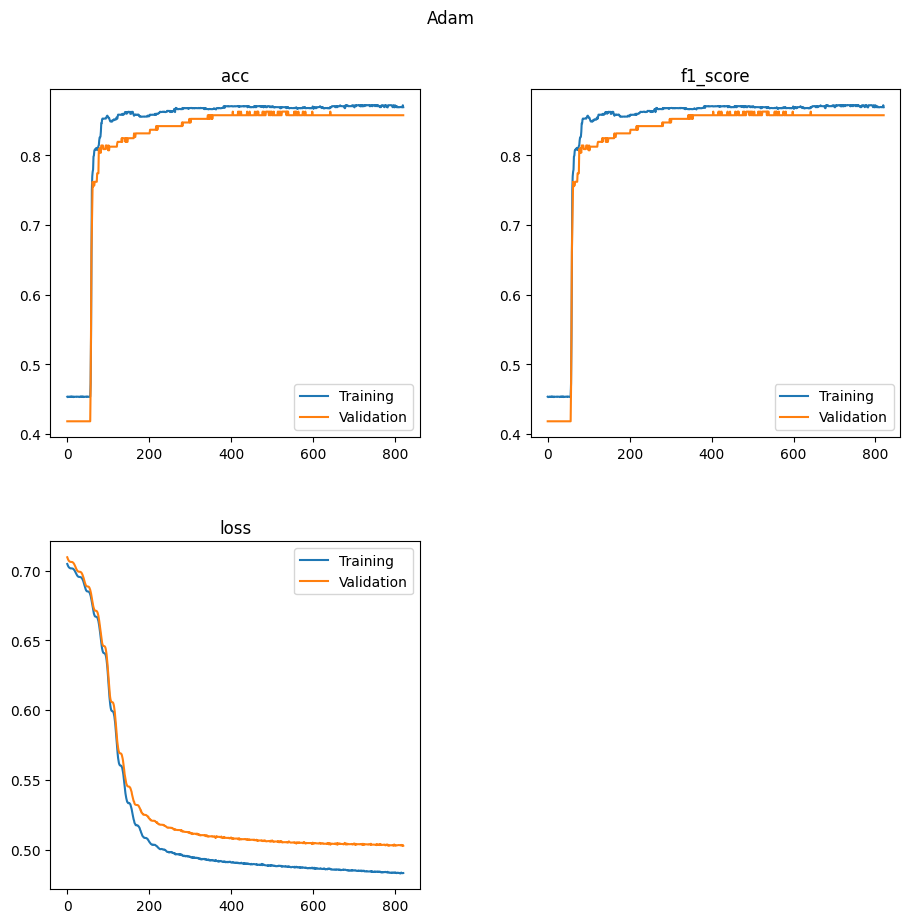

loss:
	min: 0.48296,	max: 0.70483,	cur: 0.48326
acc:
	min: 0.45308,	max: 0.87219,	cur: 0.86911
f1_score:
	min: 0.45308,	max: 0.87219,	cur: 0.86911
val_loss:
	min: 0.50262,	max: 0.70964,	cur: 0.50281
val_acc:
	min: 0.4184,	max: 0.86285,	cur: 0.85764
val_f1_score:
	min: 0.4184,	max: 0.86285,	cur: 0.85764
Epoch: 821

EarlyStoping: stop flag!!


In [77]:

EPOCH = 1000
trainer_obj.run(train_dl, test_dl, EPOCH)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

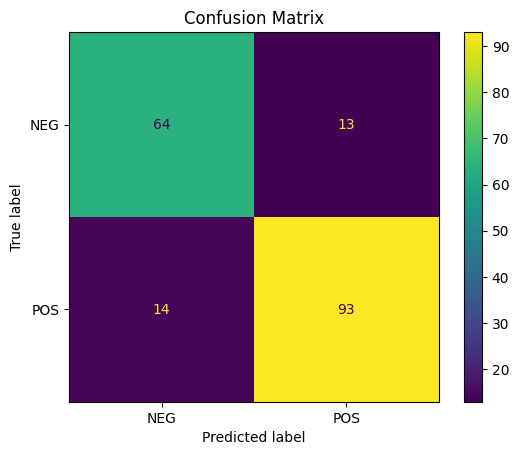

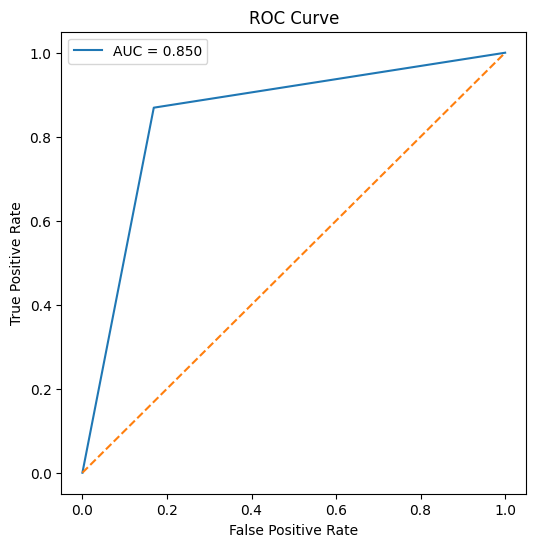

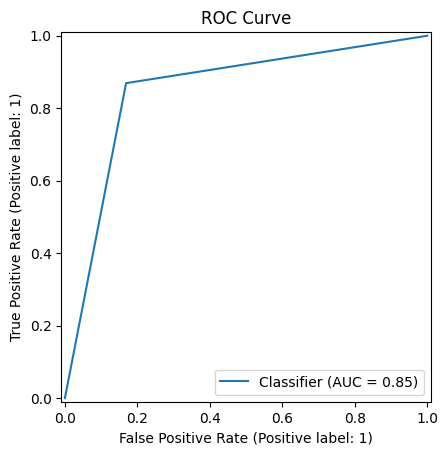

In [78]:

# Collect all predictions on the validation folds and compute the accuracy, the F1 score and the confusion matrix to make a decision.
# Report the final metrics on the held-out test dataset.
y_pred = trainer_obj.predict(test_dl)
show_metrics(y_test, y_pred, class_names=["NEG", "POS"])